#| label: lab3_intro

# Machine Learning 3 - Support Vector Machines

A SVM classifier builds a set of hyper-planes to try and separate the data by maximizing the distance between the borders and the data points.


This separation is generally not possible to achieve in the original data space. Therefore, the first step of the SVM is to project the data into a high or infinite dimensions space in which this linear separation can be done. The projection can be done with linear, polynomial, or more comonly "RBF" kernels.

![SVM](https://scikit-learn.org/stable/_images/sphx_glr_plot_separating_hyperplane_001.png "Decision border in an SVM")


In [2]:
from lab_tools import CIFAR10, evaluate_classifier, get_hog_image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from scipy.stats import ttest_rel
import warnings
warnings.filterwarnings('ignore')

dataset = CIFAR10('/Users/alice/Desktop/INFO-H501 - Pattern/CIFAR10')

scaler = StandardScaler()
X_train = scaler.fit_transform(dataset.train['hog'])
X_test = scaler.transform(dataset.test['hog'])
y_train = dataset.train['labels']
y_test = dataset.test['labels']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Pre-loading training data
Pre-loading test data
Training set: (15000, 256)
Test set: (3000, 256)


**Build a simple SVM** using [the SVC (Support Vector Classfiication) from sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC). 
**Train** it on the CIFAR dataset.

Descriptive accuracy (training set): 0.9317
CV accuracy (5-fold): 0.8141 +- 0.0077
Test set accuracy: 0.8213


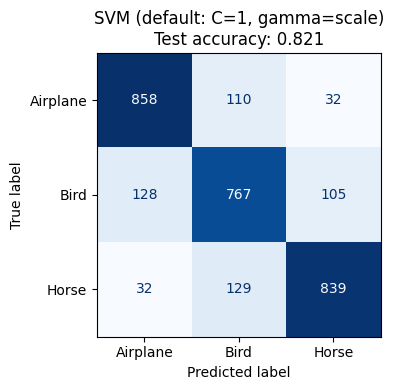


Classification report (test set):
              precision    recall  f1-score   support

    Airplane       0.84      0.86      0.85      1000
        Bird       0.76      0.77      0.76      1000
       Horse       0.86      0.84      0.85      1000

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



In [7]:
clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
print(f"Descriptive accuracy (training set): {train_acc:.4f}")

scores_default = cross_val_score(clf, X_train, y_train, cv=skf)
print(f"CV accuracy (5-fold): {scores_default.mean():.4f} +- {scores_default.std():.4f}")

test_acc = clf.score(X_test, y_test)
print(f"Test set accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_test, clf.predict(X_test))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=dataset.labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'SVM (default: C=1, gamma=scale)\nTest accuracy: {test_acc:.3f}')
plt.tight_layout()
plt.savefig('svm_default_cm.png', dpi=150)
plt.show()

print("\nClassification report (test set):")
print(classification_report(y_test, clf.predict(X_test), target_names=dataset.labels))

**Explore the classifier**. How many support vectors are there? What are support vectors?

In [9]:
all_support_vectors = clf.support_vectors_ #Each line = 1 "Support Vector" ; 1024 columns forming a 32x32 image 
vectors_per_class = clf.n_support_ #Number of "Support Vector" for each class

print(f"Total support vectors: {len(all_support_vectors)}")
print(f"As % of training set: {100*len(all_support_vectors)/len(X_train):.1f}%")
print(f"Support vectors per class:")
for label, n in zip(dataset.labels, vectors_per_class):
    print(f"  {label:<10}: {n} ({100*n/5000:.1f}% of its training examples)")
print(f"\nShape of support vector matrix: {all_support_vectors.shape}")
print(f"(Each row = 1 support vector of 256 HoG dimensions)")


Total support vectors: 9025
As % of training set: 60.2%
Support vectors per class:
  Airplane  : 2756 (55.1% of its training examples)
  Bird      : 3676 (73.5% of its training examples)
  Horse     : 2593 (51.9% of its training examples)

Shape of support vector matrix: (9025, 256)
(Each row = 1 support vector of 256 HoG dimensions)


**Try to find the best "C" (error penalty) and "gamma" parameters** using cross-validation. What influence does "C" have on the number of support vectors?

     C   # SVs  % of train    CV Acc
--------------------------------------
  0.01   14089       93.9%    0.7075
   0.1   10677       71.2%    0.7676
     1    9025       60.2%    0.8141
    10    9945       66.3%    0.8251
   100    9938       66.3%    0.8247


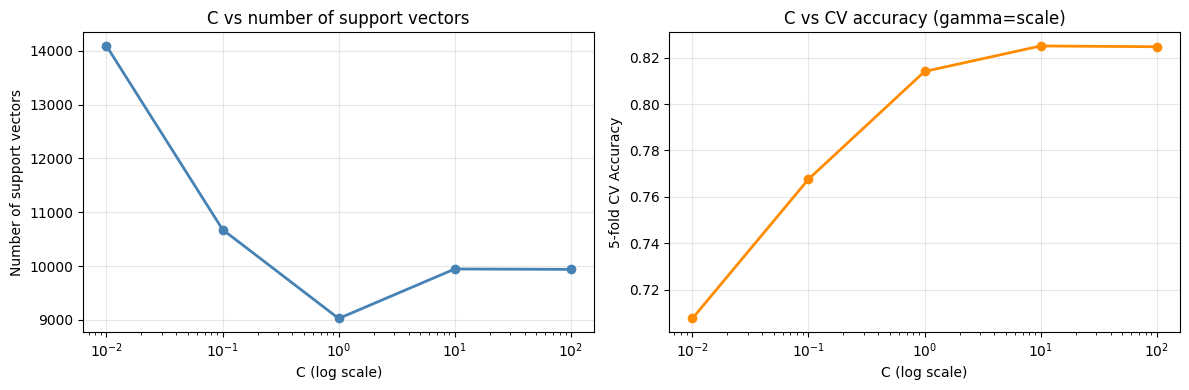

In [10]:
C_values = [0.01, 0.1, 1, 10, 100]
n_svs, cv_accs = [], []

print(f"{'C':>6}  {'# SVs':>6}  {'% of train':>10}  {'CV Acc':>8}")
print("-" * 38)

for C in C_values:
    svm = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    svm.fit(X_train, y_train)
    scores = cross_val_score(svm, X_train, y_train, cv=skf)
    n_sv = svm.n_support_.sum()
    n_svs.append(n_sv)
    cv_accs.append(scores.mean())
    print(f"{C:>6}  {n_sv:>6}  {100*n_sv/len(X_train):>9.1f}%  {scores.mean():>8.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(C_values, n_svs, '-o', color='steelblue', linewidth=2)
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('Number of support vectors')
axes[0].set_title('C vs number of support vectors')
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(C_values, cv_accs, '-o', color='darkorange', linewidth=2)
axes[1].set_xlabel('C (log scale)')
axes[1].set_ylabel('5-fold CV Accuracy')
axes[1].set_title('C vs CV accuracy (gamma=scale)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_C_sweep.png', dpi=150)
plt.show()


In [11]:
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1],
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters:  {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"Test set accuracy: {grid_search.best_estimator_.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters:  {'C': 10, 'gamma': 'scale'}
Best CV accuracy: 0.8251
Test set accuracy: 0.8323


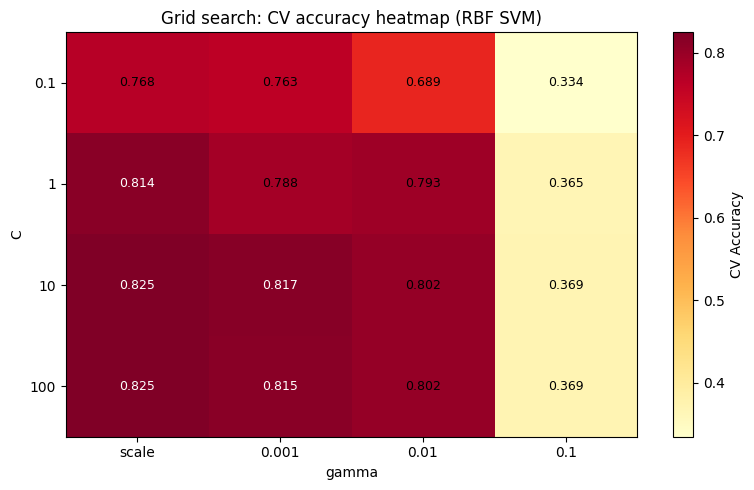

In [12]:
# Heatmap of grid search results
import pandas as pd

results = grid_search.cv_results_
mean_scores = results['mean_test_score']

# Reshape into a grid — only numeric gamma values for heatmap
C_vals     = [0.1, 1, 10, 100]
gamma_vals = ['scale', 0.001, 0.01, 0.1]

score_matrix = mean_scores.reshape(len(C_vals), len(gamma_vals))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(score_matrix, cmap='YlOrRd', aspect='auto',
               vmin=score_matrix.min(), vmax=score_matrix.max())
plt.colorbar(im, ax=ax, label='CV Accuracy')
ax.set_xticks(range(len(gamma_vals)))
ax.set_yticks(range(len(C_vals)))
ax.set_xticklabels([str(g) for g in gamma_vals])
ax.set_yticklabels([str(c) for c in C_vals])
ax.set_xlabel('gamma')
ax.set_ylabel('C')
ax.set_title('Grid search: CV accuracy heatmap (RBF SVM)')

# Annotate cells
for i in range(len(C_vals)):
    for j in range(len(gamma_vals)):
        ax.text(j, i, f'{score_matrix[i,j]:.3f}',
                ha='center', va='center', fontsize=9,
                color='black' if score_matrix[i,j] < score_matrix.max()-0.02 else 'white')

plt.tight_layout()
plt.savefig('svm_gridsearch_heatmap.png', dpi=150)
plt.show()

Best SVM — support vectors: 9945 total
  Airplane: 3120
  Bird: 3955
  Horse: 2870

Classification report (test set — best SVM):
              precision    recall  f1-score   support

    Airplane       0.85      0.86      0.85      1000
        Bird       0.78      0.79      0.78      1000
       Horse       0.87      0.85      0.86      1000

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



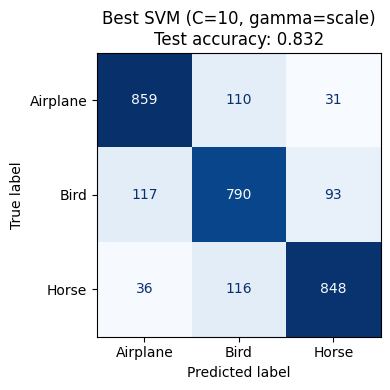

In [13]:
best_svm = grid_search.best_estimator_

print(f"Best SVM — support vectors: {best_svm.n_support_.sum()} total")
for label, n in zip(dataset.labels, best_svm.n_support_):
    print(f"  {label}: {n}")

print("\nClassification report (test set — best SVM):")
print(classification_report(y_test, best_svm.predict(X_test), target_names=dataset.labels))

# Confusion matrix
cm_best = confusion_matrix(y_test, best_svm.predict(X_test))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_best, display_labels=dataset.labels).plot(
    ax=ax, cmap='Blues', colorbar=False)
bp = grid_search.best_params_
ax.set_title(f'Best SVM (C={bp["C"]}, gamma={bp["gamma"]})\nTest accuracy: {best_svm.score(X_test, y_test):.3f}')
plt.tight_layout()
plt.savefig('svm_best_cm.png', dpi=150)
plt.show()

# Comparing algorithms

Using the best hyper-parameters that you found for each of the algorithms (kNN, Decision Trees, Random Forests, MLP, SVM):

* Re-train the models on the full training set.
* Compare their results on the test set.

In [14]:
from sklearn.linear_model import RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

X_raw_train = dataset.train['hog']
X_raw_test  = dataset.test['hog']

# Best models from each lab — update hyperparameters to match YOUR best results
all_models = {
    'Ridge (α=0.1)':       (RidgeClassifier(alpha=0.1),
                             X_raw_train, X_raw_test),
    'kNN (k=5)':           (KNeighborsClassifier(n_neighbors=5, weights='uniform'),
                             X_raw_train, X_raw_test),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=10, random_state=42),
                             X_raw_train, X_raw_test),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42),
                             X_raw_train, X_raw_test),
    'MLP (200, relu)':     (MLPClassifier(hidden_layer_sizes=(200,), activation='relu',
                             learning_rate_init=0.001, max_iter=500,
                             early_stopping=True, random_state=42),
                             X_train, X_test),
    'SVM (best)':          (best_svm, X_train, X_test),
}

all_cv_scores = {}
all_test_accs = {}

print(f"{'Method':<22} {'CV Mean':>8} {'CV Std':>8} {'Test Acc':>10}")
print("-" * 52)

for name, (clf_m, Xtr, Xte) in all_models.items():
    scores = cross_val_score(clf_m, Xtr, y_train, cv=skf)
    clf_m.fit(Xtr, y_train)
    tacc = clf_m.score(Xte, y_test)
    all_cv_scores[name] = scores
    all_test_accs[name] = tacc
    print(f"{name:<22} {scores.mean():>8.4f} {scores.std():>8.4f} {tacc:>10.4f}")


Method                  CV Mean   CV Std   Test Acc
----------------------------------------------------
Ridge (α=0.1)            0.7455   0.0074     0.7400
kNN (k=5)                0.7111   0.0052     0.7220
Decision Tree            0.5984   0.0098     0.6007
Random Forest            0.7566   0.0122     0.7693
MLP (200, relu)          0.8013   0.0075     0.8137
SVM (best)               0.8251   0.0073     0.8323


In [15]:
print("Paired t-tests vs Ridge (α=0.1) baseline:")
ridge_s = all_cv_scores['Ridge (α=0.1)']
for name, scores in all_cv_scores.items():
    if name == 'Ridge (α=0.1)': continue
    t, p = ttest_rel(scores, ridge_s)
    direction = 'better ↑' if scores.mean() > ridge_s.mean() else 'worse ↓'
    sig = '✓' if p < 0.05 else '✗'
    print(f"  {name:<22}  p={p:.6f}  {sig} {direction}")

Paired t-tests vs Ridge (α=0.1) baseline:
  kNN (k=5)               p=0.000430  ✓ worse ↓
  Decision Tree           p=0.000002  ✓ worse ↓
  Random Forest           p=0.057174  ✗ better ↑
  MLP (200, relu)         p=0.000152  ✓ better ↑
  SVM (best)              p=0.000028  ✓ better ↑


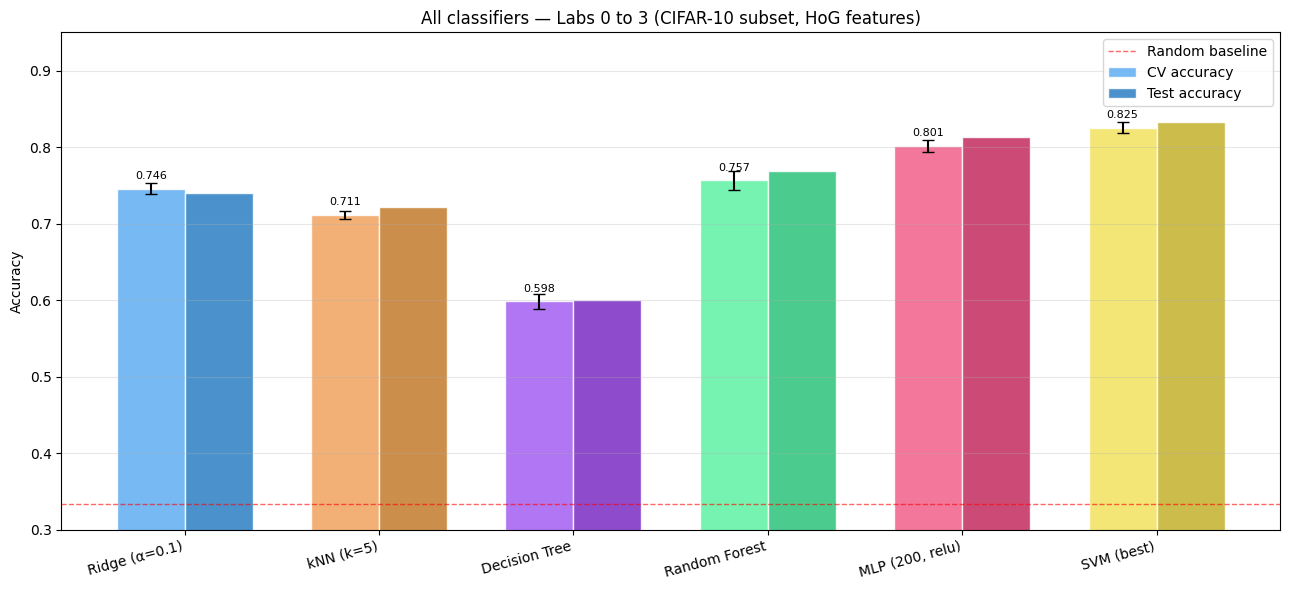

In [16]:
method_names = list(all_cv_scores.keys())
cv_means  = [all_cv_scores[m].mean() for m in method_names]
cv_stds   = [all_cv_scores[m].std()  for m in method_names]
test_accs = [all_test_accs[m]        for m in method_names]

x = np.arange(len(method_names))
w = 0.35
colors_cv   = ['#5EADF2','#F2A25E','#A25EF2','#5EF2A2','#F25E8A','#F2E25E']
colors_test = ['#2B7FC4','#C47A2B','#7A2BC4','#2BC47A','#C42B5E','#C4B12B']

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - w/2, cv_means, w, yerr=cv_stds, capsize=4,
               color=colors_cv, alpha=0.85, label='CV accuracy', edgecolor='white')
bars2 = ax.bar(x + w/2, test_accs, w,
               color=colors_test, alpha=0.85, label='Test accuracy', edgecolor='white')
ax.axhline(1/3, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Random baseline')
ax.set_xticks(x)
ax.set_xticklabels(method_names, rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('All classifiers — Labs 0 to 3 (CIFAR-10 subset, HoG features)')
ax.set_ylim(0.3, 0.95)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, mean in zip(bars1, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('all_methods_final.png', dpi=150, bbox_inches='tight')
plt.show()

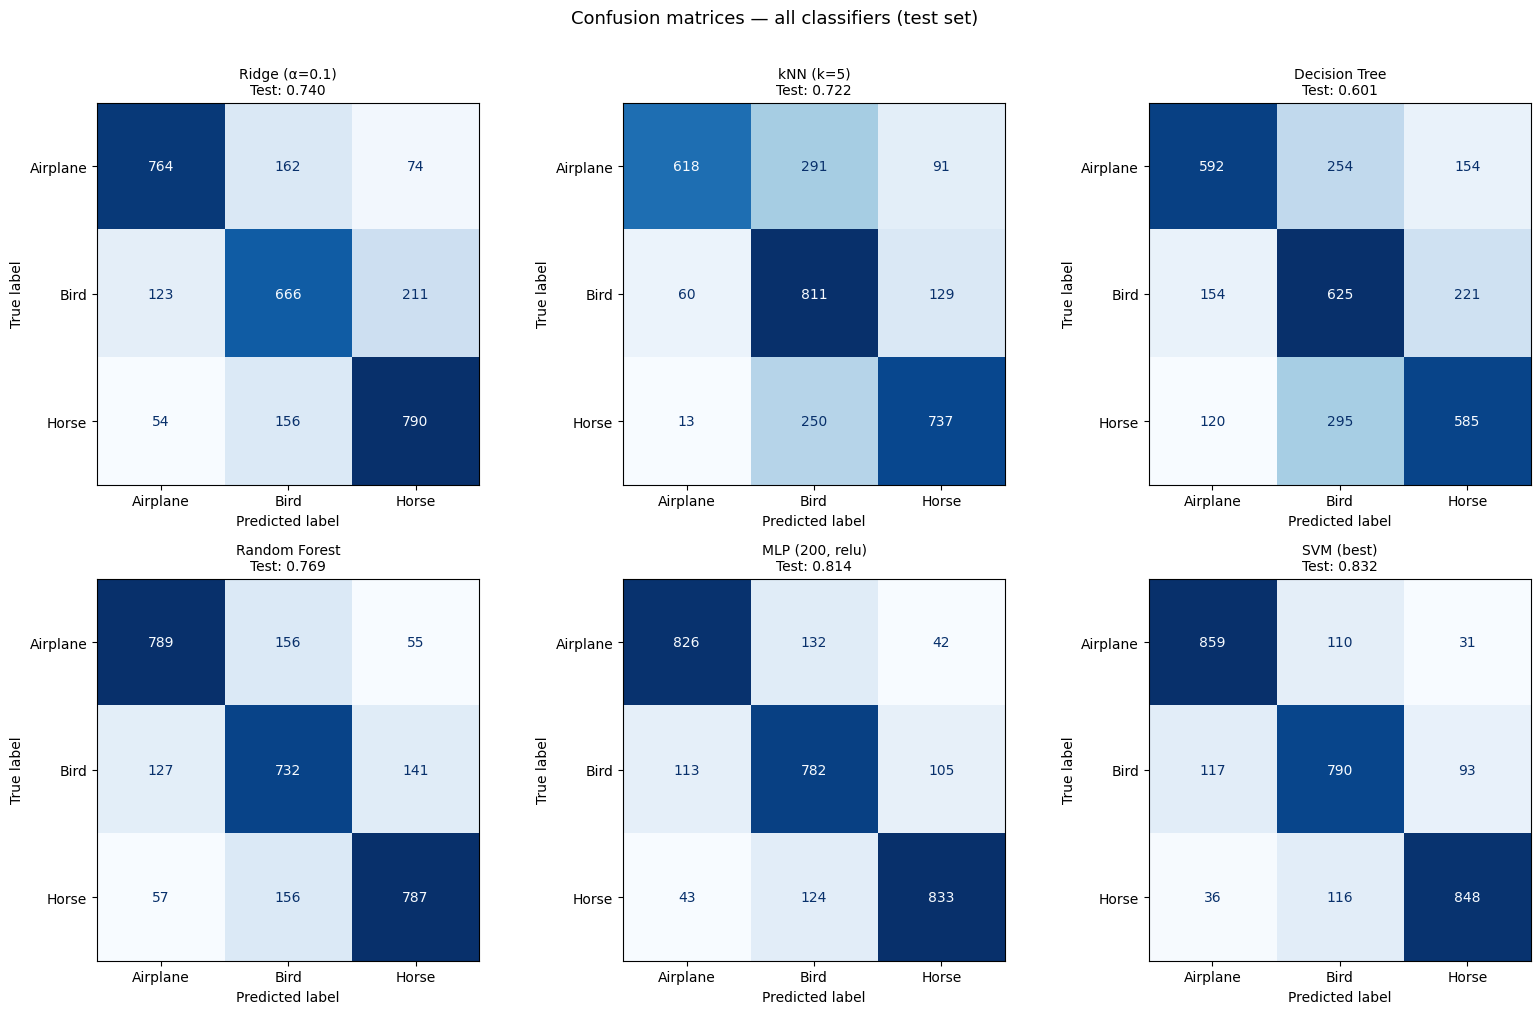

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, (clf_m, Xtr, Xte)) in zip(axes, all_models.items()):
    clf_m.fit(Xtr, y_train)
    cm = confusion_matrix(y_test, clf_m.predict(Xte))
    ConfusionMatrixDisplay(cm, display_labels=dataset.labels).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nTest: {clf_m.score(Xte, y_test):.3f}', fontsize=10)

plt.suptitle('Confusion matrices — all classifiers (test set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('all_confusion_matrices_final.png', dpi=150, bbox_inches='tight')
plt.show()